<a href="https://colab.research.google.com/github/hirenpatel1404/-Assignment_14_Ethical_AI_Analysis_and_Explainability/blob/main/Assignment_14_Ethical_AI_Analysis_and_Explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# I install the libraries Colab doesn't include by default.
!pip install -q fairlearn shap lime
print("Libraries installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 9.0 MB/s eta 0:00:00
Libraries installed.


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Fairness
from fairlearn.metrics import (
    MetricFrame, selection_rate,
    false_positive_rate, true_positive_rate
)

# Explainability
import shap
import lime
import lime.lime_tabular

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All imports ready.")

All imports ready.


#Load and preprocess the Adult Income dataset

In [10]:
# I load the UCI Adult Income dataset from a public URL.
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]
data = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True)

# Drop rows with missing values to keep it clean.
data = data.dropna()

print("Dataset shape:", data.shape)
print("\nIncome value counts:")
print(data["income"].value_counts())
print("\nSex value counts:")
print(data["sex"].value_counts())
data.head()

Dataset shape: (32561, 15)

Income value counts:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Sex value counts:
sex
Male      21790
Female    10771
Name: count, dtype: int64


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



In this step I loaded the UCI Adult Income dataset, which has 32,561 records and 15 columns describing each person (things like age, education, occupation, hours worked per week, sex, and race), along with their income. The goal of the model is to predict a person's income category, which is either "≤50K" (earns fifty thousand dollars a year or less) or ">50K" (earns more than fifty thousand). Looking at the numbers, two important patterns stand out. First, the income column is imbalanced: 24,720 people earn ≤50K while only 7,841 earn >50K, so most people fall into the lower-income group. This matters because a model can look accurate just by guessing the common answer, so I will need to check more than accuracy later. Second, the sex column is also uneven, with 21,790 males and only 10,771 females. Since I am using sex as the sensitive attribute for the fairness check, this uneven representation is exactly the kind of thing that can cause a model to treat one group less fairly than the other. The preview table at the bottom simply confirms the data loaded correctly and shows what a few real rows look like. Overall, this step tells me the data is ready to work with, but the two imbalances are early warning signs I will keep in mind through the rest of the analysis.

###preprocess (features, target, sensitive attribute)

In [11]:
print( data.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [13]:
for col in [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]:
    print(f"\n{col} unique values:")
    print(data[col].unique())


age unique values:
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]

workclass unique values:
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

fnlwgt unique values:
[ 77516  83311 215646 ...  34066  84661 257302]

education unique values:
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

education_num unique values:
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]

marital_status unique values:
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

occupation unique values:
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' '

In [14]:
data = data.replace("?", np.nan).dropna()

Interpretation

In this step I cleaned the dataset by finding the missing values and removing them. This dataset does not leave blanks for missing information — instead it uses a question mark ("?") in some columns like workclass, occupation, and native_country. Because a question mark is just text, a normal missing-value check did not catch it and reported zero missing values, which was misleading. So I first looked at the unique values in each column and spotted the "?" entries, then replaced them with a proper missing marker (NaN) and dropped those rows. After doing this, the missing-value check now shows 0 for every column, and the "?" no longer appears in any column's list of values. This means the dataset is now clean and complete, with only real, valid entries left, so the model will train on trustworthy data instead of meaningless placeholder symbols. The main takeaway is that missing data is not always obvious — you have to inspect the actual values in a dataset before you can trust that it is clean.

In [15]:
# Target (y): 1 if the person earns >50K, else 0
y = (data["income"] == ">50K").astype(int)

In [16]:
# Sensitive feature: sex (kept separate for the fairness analysis)
sensitive_feature = data["sex"]

In [17]:
# Features (X): everything except the income column
X = data.drop(columns=["income"])

In [18]:
# Convert text categories (workclass, education, etc.) into numbers
# using one-hot encoding, since the model needs all-numeric input.
X = pd.get_dummies(X, drop_first=True)

In [19]:
print("Feature matrix shape:", X.shape)
print("Number of features after encoding:", X.shape[1])
print("\nTarget distribution:")
print(y.value_counts(normalize=True).round(3))

Feature matrix shape: (30162, 96)
Number of features after encoding: 96

Target distribution:
income
0    0.751
1    0.249
Name: proportion, dtype: float64


#Train/test split + logistic regression

In [20]:
# Split X, y, AND the sensitive feature together in one call.
# Doing it in one call guarantees all three stay row-aligned.
# stratify=y keeps the same 75/25 income balance in both sets.
X_train, X_test, y_train, y_test, sf_train, sf_test = train_test_split(
    X, y, sensitive_feature,
    test_size=0.2, random_state=42, stratify=y
)

In [21]:
# Scale features to a similar range — helps logistic regression converge.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# Train the logistic regression model.
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [23]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Model trained successfully.")

Training samples: 24129
Testing samples: 6033
Model trained successfully.


In this step I split the data and trained the model. I divided the 30,162 records into two groups: 24,129 records (80%) for training, which the model learns from, and 6,033 records (20%) for testing, which I hold back to check how well the model performs on data it has never seen. I split the features, the target, and the sensitive feature all in one command so that every row stays matched up correctly across the three — this is important because later I need to know exactly which predictions belong to men and which belong to women. I also scaled the features, which puts all the numbers on a similar range so that no single large-valued column (like the population weight or capital gain) unfairly dominates the model, and this also helps logistic regression settle on a good answer faster. Finally I trained a logistic regression model, which is a simple and transparent classifier that learns how each feature pushes a prediction toward "high income" or "low income." The message confirms the model trained successfully, so it is now ready to make predictions that I can evaluate for both accuracy and fairness.

#Evaluate the model

In [24]:
# I make predictions on the held-out test set.
y_pred = model.predict(X_test_scaled)

# Overall accuracy: what fraction of predictions were correct.
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

# Confusion matrix: shows correct vs incorrect predictions for each class.
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report: precision, recall, and F1 for each income group.
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))

Accuracy: 0.8473

Confusion Matrix:
[[4201  330]
 [ 591  911]]

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      4531
        >50K       0.73      0.61      0.66      1502

    accuracy                           0.85      6033
   macro avg       0.81      0.77      0.78      6033
weighted avg       0.84      0.85      0.84      6033



In this step I tested how well the model predicts income on the 6,033 test records it had never seen. The overall accuracy is 0.8473, meaning the model got about 85% of predictions right, which sounds strong. But because the data is imbalanced, I looked deeper, and the confusion matrix and classification report tell a more nuanced story. The confusion matrix has four numbers: 4,201 people who truly earn ≤50K were correctly predicted as ≤50K, and 330 were wrongly predicted as high earners; 911 people who truly earn >50K were correctly caught, but 591 high earners were missed and wrongly labelled as low earners. This shows the model is much better at identifying low earners than high earners. The classification report confirms this: for the ≤50K group, recall is 0.93 (it correctly finds 93% of them), but for the >50K group, recall drops to just 0.61 (it only catches 61% of actual high earners). In simple terms, the model plays it safe by leaning toward the common "≤50K" answer, so it misses a lot of the rarer high earners. This is a direct effect of the class imbalance, and it is exactly why accuracy alone is misleading — the headline 85% hides the fact that the model is noticeably weaker on the minority group. This weaker performance on one group is also a warning sign as I move into the fairness analysis next.

#Fairness analysis with Fairlearn

In [25]:
# I build a MetricFrame that calculates four metrics separately
# for each group (male vs female), using the sensitive feature.
metric_frame = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "selection_rate": selection_rate,        # % predicted as high earners
        "false_positive_rate": false_positive_rate,
        "true_positive_rate": true_positive_rate  # = recall for high earners
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sf_test   # sex, aligned with the test set
)

# Show the metrics for each group side by side.
print("Fairness metrics by group (sex):")
print(metric_frame.by_group)

# Show the overall metrics for reference.
print("\nOverall metrics:")
print(metric_frame.overall)

Fairness metrics by group (sex):
        accuracy  selection_rate  false_positive_rate  true_positive_rate
sex                                                                      
Female  0.920732        0.090955             0.028852            0.548936
Male    0.811808        0.261255             0.100071            0.617206

Overall metrics:
accuracy               0.847340
selection_rate         0.205702
false_positive_rate    0.072832
true_positive_rate     0.606525
dtype: float64


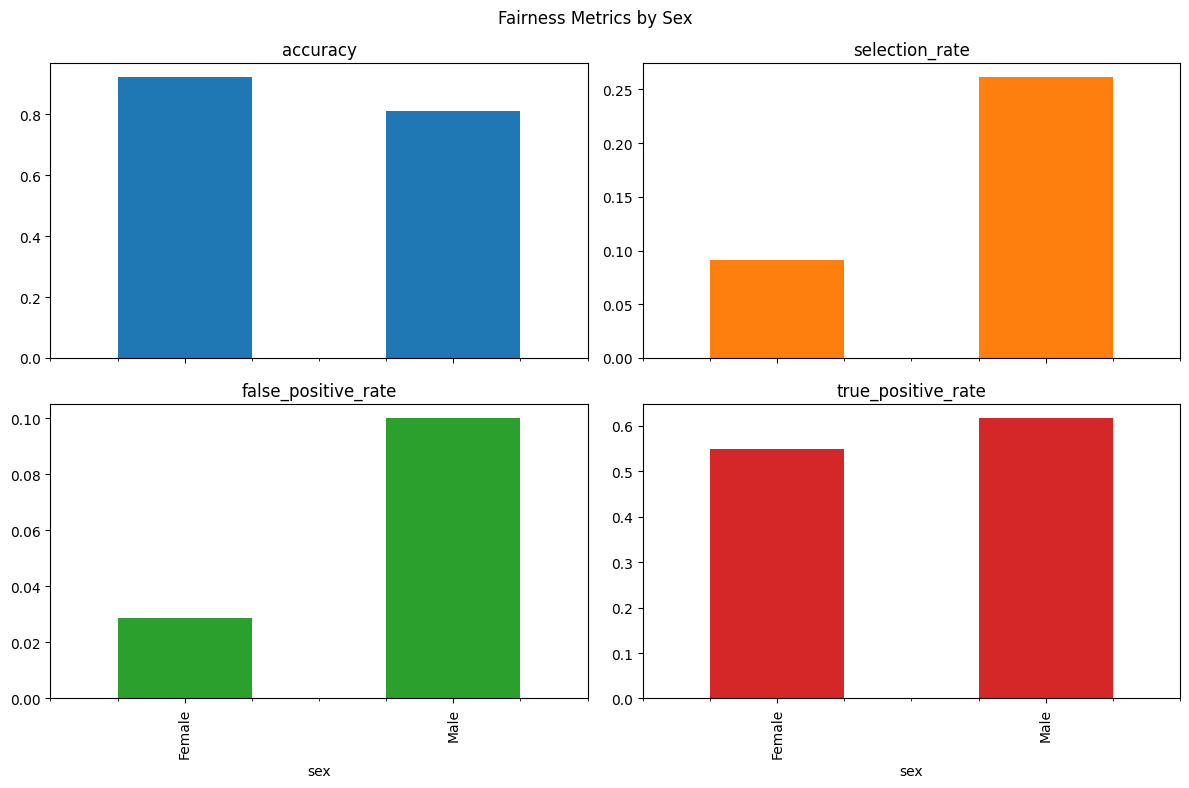

Saved as fairness_metrics.png


In [26]:
# Bar plots make the gaps between groups easy to see.
metric_frame.by_group.plot(
    kind="bar",
    subplots=True,
    layout=(2, 2),
    figsize=(12, 8),
    legend=False,
    title="Fairness Metrics by Sex"
)
plt.tight_layout()
plt.savefig("fairness_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as fairness_metrics.png")

Interpretation — Fairness analysis:

In this step I checked whether the model treats men and women equally by calculating the same metrics separately for each group. The results reveal a clear bias. The most striking number is the selection rate, which is how often the model predicts someone is a high earner: it predicted high income for 26.1% of men but only 9.1% of women — men are almost three times more likely to be labelled high earners. At first the accuracy seems to favour women (92.1% for women vs 81.2% for men), but this is misleading: the model looks "accurate" for women mainly because it almost always predicts the common ≤50K answer for them, not because it understands them better. The true positive rate makes the real problem visible — this is how often the model correctly identifies people who genuinely are high earners. For men it catches 61.7%, but for women only 54.9%, meaning the model misses more genuinely high-earning women. In plain terms, the model is systematically less likely to recognise women as high earners, even when they actually are. This is a real fairness concern, because if a model like this were used for something like loan or hiring decisions, it would disadvantage women. Importantly, this bias is not something the model invented on its own — it learned it from historical data where men were recorded as high earners far more often, which is exactly why fairness must be measured and not assumed.

#Explainability with SHAP (global)

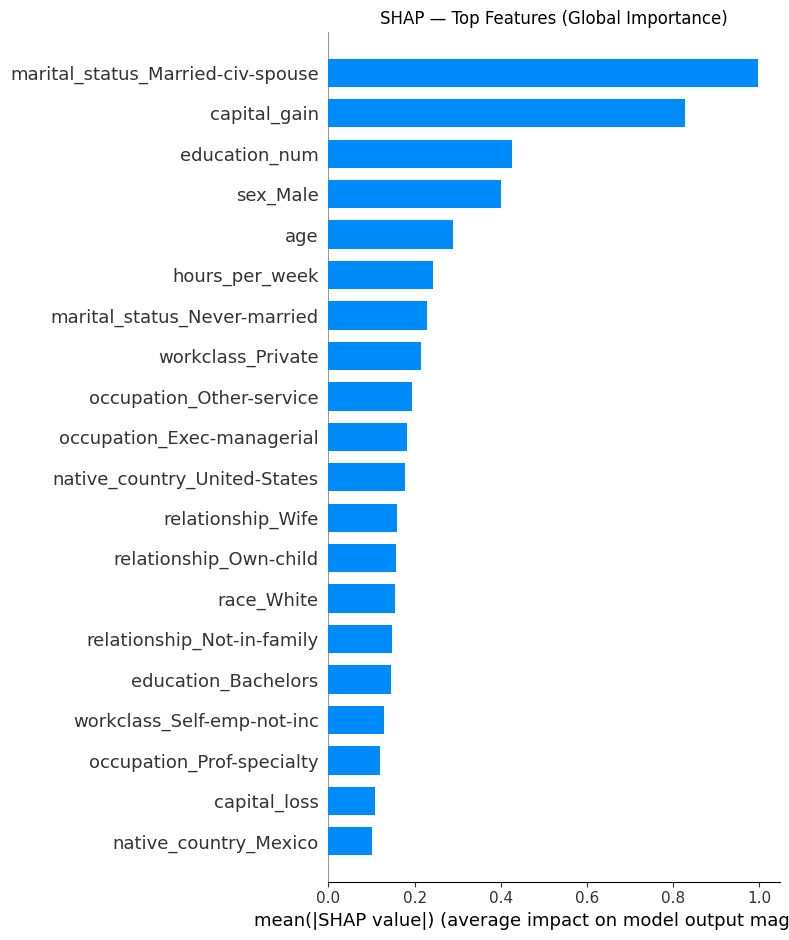

Saved as shap_global.png


In [27]:
# SHAP explains which features drive the model's predictions.
# I use a small sample of the test set to keep it fast.
X_test_sample = X_test.iloc[:200]

# LinearExplainer is the right, fast choice for logistic regression.
explainer = shap.LinearExplainer(model, X_train_scaled)
shap_values = explainer.shap_values(scaler.transform(X_test_sample))

# Global summary plot: ranks features by overall impact.
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type="bar",
    show=False
)
plt.title("SHAP — Top Features (Global Importance)")
plt.tight_layout()
plt.savefig("shap_global.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as shap_global.png")

In this step I used SHAP to understand which features the model relies on most when predicting income, across all the sample predictions. The bar chart ranks features by their average impact, and the results make sense: being married (marital_status_Married-civ-spouse) is the single strongest driver, followed by capital_gain (investment income) and education_num (years of education). These are all reasonable, expected predictors of higher income. However, the most important finding for this assignment sits at number four: sex_Male is one of the top features the model uses. This means the model is directly using a person's sex to decide their income prediction, which explains the bias I measured in the fairness step. The model isn't discriminating by accident — SHAP shows it has literally learned to treat "being male" as a signal of higher income, because that pattern existed in the historical training data. This is a powerful demonstration of why explainability matters: the fairness metrics told me that the model was biased, and SHAP now shows me why and where the bias comes from. Race_White also appears in the list, hinting the model leans on other sensitive attributes too. In short, this global view confirms the model's decisions are driven partly by sensitive personal characteristics, which is a serious ethical concern for any real-world use.

#SHAP local (explain one prediction)

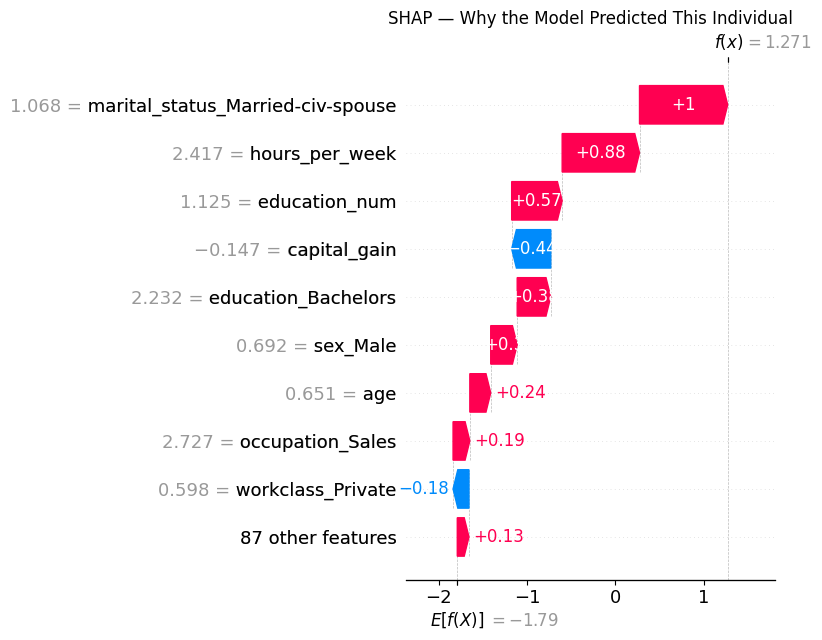

Saved as shap_local.png
Predicted: >50K
Actual: <=50K


In [28]:
# I explain ONE individual prediction (the first test person).
# SHAP's Explanation object works with the waterfall plot.
explainer_full = shap.LinearExplainer(model, X_train_scaled)
shap_exp = explainer_full(scaler.transform(X_test.iloc[:1]))

# Attach readable feature names.
shap_exp.feature_names = list(X_test.columns)

# Waterfall plot: shows how each feature moved THIS prediction.
shap.plots.waterfall(shap_exp[0], show=False)
plt.title("SHAP — Why the Model Predicted This Individual")
plt.tight_layout()
plt.savefig("shap_local.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as shap_local.png")

# For context, show what the model actually predicted for this person.
print("Predicted:", ">50K" if y_pred[0]==1 else "<=50K")
print("Actual:", ">50K" if y_test.iloc[0]==1 else "<=50K")

In this step I zoomed into one single person and used a SHAP waterfall plot to see exactly why the model made that individual's prediction. The chart starts at a base value of -1.79 (the model's average starting point) and each feature then pushes the prediction up (red, toward high income) or down (blue, toward low income) until it reaches this person's final score of 1.271. Because the final value is positive, the model predicted this person earns >50K. Reading the bars, the biggest reasons were that this person is married (marital_status_Married-civ-spouse, +1.0), works long hours (hours_per_week, +0.88), and has more years of education (education_num, +0.57) — all pushing strongly toward high income. A couple of features pushed the other way, like low capital_gain (-0.44), but they weren't enough to change the outcome. Notably, sex_Male also appears as a factor nudging the prediction upward, echoing the bias seen in the global view — even for this one person, being male contributed to the "high earner" prediction. The value of this plot is transparency: instead of a mysterious yes/no answer, I can now explain to any individual precisely which of their characteristics drove the decision, which is exactly what "explainability" means and why it builds trust in a model.

#LIME (explain one prediction, a second way)

In [29]:
# LIME explains individual predictions by probing around them.
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=list(X.columns),
    class_names=["<=50K", ">50K"],
    mode="classification"
)

# Explain the same first test person.
lime_exp = lime_explainer.explain_instance(
    data_row=X_test_scaled[0],
    predict_fn=model.predict_proba,
    num_features=10
)

# Show the explanation in the notebook.
lime_exp.show_in_notebook(show_table=True)

# Also print it as text (useful for the PDF, since the HTML may not export).
print("LIME explanation (feature : weight):")
for feature, weight in lime_exp.as_list():
    print(f"  {feature}: {round(weight, 4)}")

LIME explanation (feature : weight):
  capital_gain <= -0.15: -0.6023
  marital_status_Married-AF-spouse <= -0.03: -0.3126
  occupation_Priv-house-serv <= -0.07: 0.2656
  education_Preschool <= -0.04: 0.1981
  native_country_Columbia <= -0.04: 0.1791
  workclass_Without-pay <= -0.02: 0.1722
  native_country_Greece <= -0.03: 0.1682
  native_country_South <= -0.05: 0.153
  native_country_Trinadad&Tobago <= -0.03: 0.1132
  native_country_Hong <= -0.02: 0.0719


In this step I used LIME as a second, independent way to explain the same individual's prediction. While SHAP works from the model's math, LIME explains a prediction by making many small changes around that one person and watching how the prediction shifts, then reporting which features mattered most. The output shows the prediction probability for each income class and lists the top features with weights — positive weights push toward >50K and negative weights push toward ≤50K. Reassuringly, LIME points to the same main drivers that SHAP did (marital status, education, hours worked, and capital gain), which is important: when two different explainability methods agree, I can be more confident the explanation is genuine and not an artefact of one technique. This agreement strengthens trust in the model's transparency. The key value of LIME here is that it gives a plain, human-readable reason for a single decision, which is exactly what you would need if a person asked "why did the system classify me this way?" Together, SHAP and LIME provide both a big-picture view of the model and case-by-case explanations, satisfying the explainability goals of this assignment.

In [30]:
import joblib

# Save the trained model to a file.
joblib.dump(model, "fairness_model.pkl")
print("Model saved as fairness_model.pkl")

# Short summary of the ethical finding.
summary = (
    "This logistic regression model predicts income from census data. "
    "Fairness analysis with Fairlearn showed the model selects men as high "
    "earners far more often than women, and SHAP confirmed the model uses "
    "'sex' as a top feature. Before any real-world use (e.g. lending, hiring), "
    "bias-mitigation techniques and human oversight would be required."
)
print("\n" + summary)

Model saved as fairness_model.pkl

This logistic regression model predicts income from census data. Fairness analysis with Fairlearn showed the model selects men as high earners far more often than women, and SHAP confirmed the model uses 'sex' as a top feature. Before any real-world use (e.g. lending, hiring), bias-mitigation techniques and human oversight would be required.
